# Sesgo y Varianza en Machine Learning
## Predicción de Asistencia en Campo de Golf

Este notebook demuestra los conceptos de **sesgo** y **varianza** usando un ejemplo práctico: predecir cuántos jugadores asistirán a un campo de golf basándose en condiciones climáticas.

### Contexto del Problema
- **Dataset**: 28 días de datos
- **Desafío**: Con solo 28 observaciones, dividir en 14 días de entrenamiento y 14 de prueba limita las combinaciones climáticas que el modelo puede aprender
- **Objetivo**: Entender por qué los modelos simples (alto sesgo) y complejos (alta varianza) funcionan mal, y encontrar el equilibrio óptimo

### Conceptos Clave
1. **Sesgo (Bias)**: Error por asumir demasiadas simplificaciones. Modelos con alto sesgo no capturan patrones complejos.
2. **Varianza (Variance)**: Sensibilidad excesiva a los datos de entrenamiento. Modelos con alta varianza se sobreajustan.
3. **Desafío del Trade-off**: Encontrar el punto óptimo entre simplificar y capturar compleidad.

In [1]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# Configurar estilo de visualizaciones
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ Librerías importadas correctamente")

✓ Librerías importadas correctamente


## Sección 1: Generar Dataset de Asistencia a Campo de Golf

Crearemos un dataset sintético de 28 días con variables realistas que influyen en la asistencia de jugadores.

In [3]:
# Establecer semilla para reproducibilidad
np.random.seed(42)

# Crear dataset de 28 días
n_days = 28
dias = np.arange(1, n_days + 1)

# Generar variables climáticas y otros factores
temperatura = np.random.uniform(10, 35, n_days)  # °C
humedad = np.random.uniform(30, 90, n_days)  # %
viento = np.random.uniform(0, 30, n_days)  # km/h

# Tipo de clima (soleado=2, nublado=1, lluvioso=0)
tipo_clima = np.random.choice([0, 1, 2], n_days, p=[0.2, 0.3, 0.5])
clima_nombres = ['Lluvioso', 'Nublado', 'Soleado']

# El número de jugadores depende de las condiciones climáticas
# Relación: Soleado y temperatura media = más jugadores
# Lluvioso y viento fuerte = menos jugadores
jugadores_base = np.where(tipo_clima == 2, 80.0, np.where(tipo_clima == 1, 60.0, 40.0))
jugadores_base += (temperatura - 20) * 1.5  # Efecto temperatura
jugadores_base -= humedad * 0.3  # Efecto humedad
jugadores_base -= viento * 0.5  # Efecto viento

# Agregar ruido realista
ruido = np.random.normal(0, 5, n_days)
jugadores = np.clip(jugadores_base + ruido, 15, 120).astype(int)

# Crear DataFrame
df = pd.DataFrame({
    'Día': dias,
    'Tipo_Clima': [clima_nombres[int(c)] for c in tipo_clima],
    'Temperatura_C': np.round(temperatura, 1),
    'Humedad_Pct': np.round(humedad, 1),
    'Viento_kmh': np.round(viento, 1),
    'Jugadores': jugadores
})

# Guardar como CSV
csv_path = 'c:\\xampp\\htdocs\\codigo\\golf_asistencia_28dias.csv'
df.to_csv(csv_path, index=False, encoding='utf-8')

print(f"✓ Dataset creado y guardado en: {csv_path}")
print(f"\nDataset de 28 días:\n")
print(df.head(10))
print(f"\n... (mostrando primeras 10 filas de {len(df)} total)")
print(f"\nResumen estadístico:")
print(df.describe())

✓ Dataset creado y guardado en: c:\xampp\htdocs\codigo\golf_asistencia_28dias.csv

Dataset de 28 días:

   Día Tipo_Clima  Temperatura_C  Humedad_Pct  Viento_kmh  Jugadores
0    1    Nublado           19.4         65.5         2.7         42
1    2    Nublado           33.8         32.8         5.9         69
2    3    Soleado           28.3         66.5         1.4         69
3    4    Soleado           25.0         40.2         9.8         73
4    5    Soleado           13.9         33.9        11.7         55
5    6    Nublado           13.9         86.9         8.1         25
6    7   Lluvioso           11.5         87.9        24.9         15
7    8    Soleado           31.7         78.5        10.7         66
8    9    Soleado           25.0         48.3         8.4         66
9   10    Soleado           27.7         35.9        16.3         65

... (mostrando primeras 10 filas de 28 total)

Resumen estadístico:
             Día  Temperatura_C  Humedad_Pct  Viento_kmh  Jugadores


## Sección 2: Exploración y Visualización de Datos

Analicemos las relaciones entre variables climáticas y asistencia de jugadores.

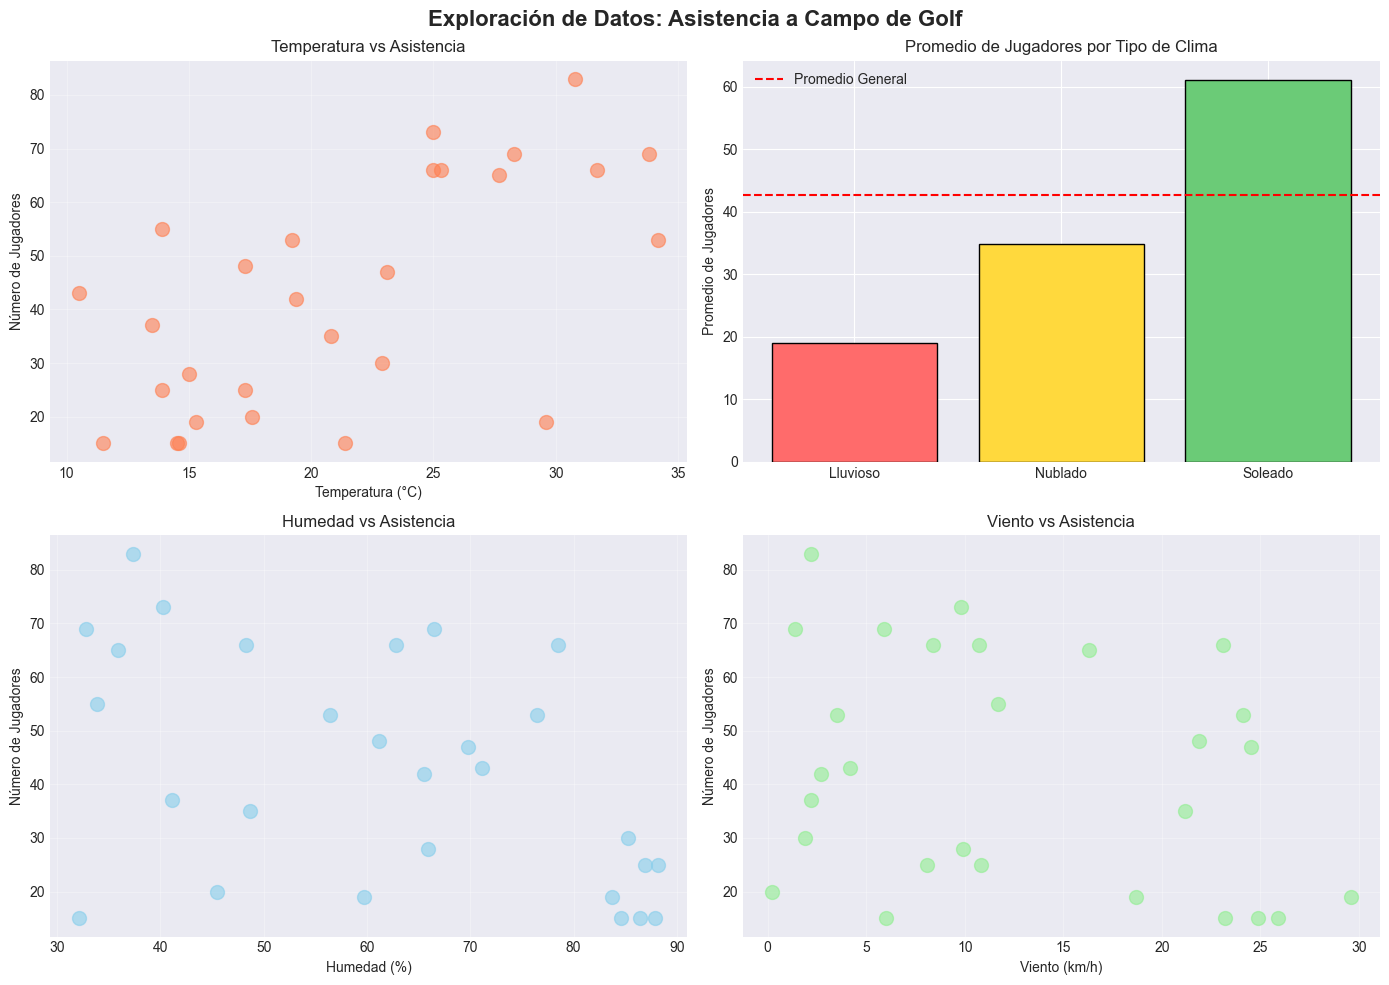

✓ Gráficas de exploración creadas

Matriz de Correlación:
               Temperatura_C  Humedad_Pct  Viento_kmh  Jugadores
Temperatura_C          1.000       -0.197      -0.005      0.636
Humedad_Pct           -0.197        1.000       0.074     -0.478
Viento_kmh            -0.005        0.074       1.000     -0.276
Jugadores              0.636       -0.478      -0.276      1.000


In [4]:
# Cargar datos
df = pd.read_csv('c:\\xampp\\htdocs\\codigo\\golf_asistencia_28dias.csv')

# Crear figura con subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploración de Datos: Asistencia a Campo de Golf', fontsize=16, fontweight='bold')

# 1. Temperatura vs Jugadores
axes[0, 0].scatter(df['Temperatura_C'], df['Jugadores'], alpha=0.6, s=100, color='coral')
axes[0, 0].set_xlabel('Temperatura (°C)')
axes[0, 0].set_ylabel('Número de Jugadores')
axes[0, 0].set_title('Temperatura vs Asistencia')
axes[0, 0].grid(True, alpha=0.3)

# 2. Tipo de Clima vs Jugadores
df_clima = df.groupby('Tipo_Clima')['Jugadores'].mean()
colors_clima = ['#FF6B6B', '#FFD93D', '#6BCB77']
axes[0, 1].bar(df_clima.index, df_clima.values, color=colors_clima, edgecolor='black')
axes[0, 1].set_ylabel('Promedio de Jugadores')
axes[0, 1].set_title('Promedio de Jugadores por Tipo de Clima')
axes[0, 1].axhline(y=df['Jugadores'].mean(), color='r', linestyle='--', label='Promedio General')
axes[0, 1].legend()

# 3. Humedad vs Jugadores
axes[1, 0].scatter(df['Humedad_Pct'], df['Jugadores'], alpha=0.6, s=100, color='skyblue')
axes[1, 0].set_xlabel('Humedad (%)')
axes[1, 0].set_ylabel('Número de Jugadores')
axes[1, 0].set_title('Humedad vs Asistencia')
axes[1, 0].grid(True, alpha=0.3)

# 4. Viento vs Jugadores
axes[1, 1].scatter(df['Viento_kmh'], df['Jugadores'], alpha=0.6, s=100, color='lightgreen')
axes[1, 1].set_xlabel('Viento (km/h)')
axes[1, 1].set_ylabel('Número de Jugadores')
axes[1, 1].set_title('Viento vs Asistencia')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('c:\\xampp\\htdocs\\codigo\\01_exploracion_datos.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráficas de exploración creadas")

# Matriz de correlación numérica
print("\nMatriz de Correlación:")
df_numerico = df[['Temperatura_C', 'Humedad_Pct', 'Viento_kmh', 'Jugadores']]
print(df_numerico.corr().round(3))

## Sección 3: Preparación de Datos - Train-Test Split

Dividimos los 28 días en 14 días de entrenamiento y 14 de prueba. Este es el desafío clave: con tan pocos datos, es difícil que ambos conjuntos tengan todas las combinaciones de clima.

In [5]:
# Preparar datos para modelos ML
# Codificar variable categórica
le = LabelEncoder()
df['Tipo_Clima_Encoded'] = le.fit_transform(df['Tipo_Clima'])

# Separar features y target
X = df[['Temperatura_C', 'Humedad_Pct', 'Viento_kmh', 'Tipo_Clima_Encoded']]
y = df['Jugadores']

# Dividir en train (14 días) y test (14 días)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)

print(f"✓ Datos divididos:")
print(f"  Entrenamiento: {len(X_train)} días")
print(f"  Prueba: {len(X_test)} días")

# Normalizar features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✓ Features normalizados usando StandardScaler")

# Mostrar distribución de clima en train y test
print("\nDistribución de clima en conjunto de ENTRENAMIENTO:")
print(df.iloc[X_train.index]['Tipo_Clima'].value_counts().sort_index())

print("\nDistribución de clima en conjunto de PRUEBA:")
print(df.iloc[X_test.index]['Tipo_Clima'].value_counts().sort_index())

print("\n⚠️  NOTA: Observe cómo la división aleatoria resultó en diferentes")
print("    distribuciones de clima entre train y test. Este es el desafío")
print("    con datos limitados: falta representación uniforme.")

✓ Datos divididos:
  Entrenamiento: 14 días
  Prueba: 14 días

✓ Features normalizados usando StandardScaler

Distribución de clima en conjunto de ENTRENAMIENTO:
Tipo_Clima
Lluvioso    4
Nublado     3
Soleado     7
Name: count, dtype: int64

Distribución de clima en conjunto de PRUEBA:
Tipo_Clima
Lluvioso    2
Nublado     7
Soleado     5
Name: count, dtype: int64

⚠️  NOTA: Observe cómo la división aleatoria resultó en diferentes
    distribuciones de clima entre train y test. Este es el desafío
    con datos limitados: falta representación uniforme.


## Sección 4: Entrenamiento de Modelos con Diferentes Complejidades

Entrenaremos 5 modelos diferentes para ilustrar el trade-off sesgo-varianza:
1. **Regresión Lineal**: Alta sesgo, baja varianza (underfitting)
2. **Polinomio grado 2**: Sesgo moderado, varianza moderada
3. **Polinomio grado 3**: Sesgo bajo, varianza moderada
4. **Polinomio grado 5**: Sesgo muy bajo, alta varianza (overfitting)
5. **Árbol de Decisión**: Muy flexible, puede captar ruido (overfitting)

In [6]:
# Diccionario para almacenar modelos y resultados
modelos = {}
resultados = []

# 1. Regresión Lineal (Alto sesgo, baja varianza)
print("Entrenando modelos...\n")

# Modelo 1: Regresión Lineal
modelo1 = LinearRegression()
modelo1.fit(X_train_scaled, y_train)
modelos['Lineal'] = modelo1

y_train_pred_1 = modelo1.predict(X_train_scaled)
y_test_pred_1 = modelo1.predict(X_test_scaled)

mse_train_1 = mean_squared_error(y_train, y_train_pred_1)
mse_test_1 = mean_squared_error(y_test, y_test_pred_1)
r2_train_1 = r2_score(y_train, y_train_pred_1)
r2_test_1 = r2_score(y_test, y_test_pred_1)

resultados.append({
    'Modelo': 'Regresión Lineal',
    'Complejidad': 'Baja',
    'Sesgo': 'Alto',
    'Varianza': 'Baja',
    'MSE_Train': mse_train_1,
    'MSE_Test': mse_test_1,
    'R2_Train': r2_train_1,
    'R2_Test': r2_test_1,
    'y_pred_train': y_train_pred_1,
    'y_pred_test': y_test_pred_1
})

# Modelos 2-4: Polinomios de grado 2, 3, 5
for degree in [2, 3, 5]:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)
    
    modelo = LinearRegression()
    modelo.fit(X_train_poly, y_train)
    modelos[f'Polinomio_grado_{degree}'] = modelo
    
    y_train_pred = modelo.predict(X_train_poly)
    y_test_pred = modelo.predict(X_test_poly)
    
    mse_train = mean_squared_error(y_train, y_train_pred)
    mse_test = mean_squared_error(y_test, y_test_pred)
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    
    sesgo_desc = 'Moderado' if degree <= 3 else 'Bajo'
    varianza_desc = 'Moderada' if degree <= 3 else 'Alta'
    complejidad = 'Media' if degree == 2 else ('Media-Alta' if degree == 3 else 'Muy Alta')
    
    resultados.append({
        'Modelo': f'Polinomio Grado {degree}',
        'Complejidad': complejidad,
        'Sesgo': sesgo_desc,
        'Varianza': varianza_desc,
        'MSE_Train': mse_train,
        'MSE_Test': mse_test,
        'R2_Train': r2_train,
        'R2_Test': r2_test,
        'y_pred_train': y_train_pred,
        'y_pred_test': y_test_pred
    })

# Modelo 5: Árbol de Decisión (Muy flexible - overfitting)
modelo_tree = DecisionTreeRegressor(max_depth=10, random_state=42)
modelo_tree.fit(X_train_scaled, y_train)
modelos['Árbol_Decisión'] = modelo_tree

y_train_pred_tree = modelo_tree.predict(X_train_scaled)
y_test_pred_tree = modelo_tree.predict(X_test_scaled)

mse_train_tree = mean_squared_error(y_train, y_train_pred_tree)
mse_test_tree = mean_squared_error(y_test, y_test_pred_tree)
r2_train_tree = r2_score(y_train, y_train_pred_tree)
r2_test_tree = r2_score(y_test, y_test_pred_tree)

resultados.append({
    'Modelo': 'Árbol de Decisión',
    'Complejidad': 'Muy Alta',
    'Sesgo': 'Muy Bajo',
    'Varianza': 'Muy Alta',
    'MSE_Train': mse_train_tree,
    'MSE_Test': mse_test_tree,
    'R2_Train': r2_train_tree,
    'R2_Test': r2_test_tree,
    'y_pred_train': y_train_pred_tree,
    'y_pred_test': y_test_pred_tree
})

# Crear tabla de resultados
df_resultados = pd.DataFrame(resultados)
print("✓ 5 modelos entrenados exitosamente\n")
print("=" * 100)
print("RESUMEN DE MODELOS Y ERRORES")
print("=" * 100)
print(df_resultados[['Modelo', 'Complejidad', 'Sesgo', 'Varianza', 'MSE_Train', 'MSE_Test', 'R2_Test']].to_string(index=False))
print("=" * 100)

Entrenando modelos...

✓ 5 modelos entrenados exitosamente

RESUMEN DE MODELOS Y ERRORES
           Modelo Complejidad    Sesgo Varianza    MSE_Train    MSE_Test   R2_Test
 Regresión Lineal        Baja     Alto     Baja 4.575657e+01   23.901199  0.945563
Polinomio Grado 2       Media Moderado Moderada 3.804563e-28  121.037625  0.724326
Polinomio Grado 3  Media-Alta Moderado Moderada 5.256068e-28  193.980782  0.558192
Polinomio Grado 5    Muy Alta     Bajo     Alta 4.579901e-28 1163.167913 -1.649216
Árbol de Decisión    Muy Alta Muy Bajo Muy Alta 0.000000e+00  408.071429  0.070582


## Sección 5: Análisis Detallado del Trade-off Sesgo-Varianza

In [7]:
# Análisis detallado de errores
print("\n" + "=" * 100)
print("ANÁLISIS DETALLADO: SESGO Y VARIANZA")
print("=" * 100)

for idx, row in df_resultados.iterrows():
    modelo_name = row['Modelo']
    mse_train = row['MSE_Train']
    mse_test = row['MSE_Test']
    r2_test = row['R2_Test']
    
    # Calcular brecha entre train y test (indicador de varianza)
    brecha = mse_test - mse_train
    rmse_test = np.sqrt(mse_test)
    mae_test = mean_absolute_error(y_test, row['y_pred_test'])
    
    print(f"\n{idx+1}. {modelo_name}")
    print(f"   {'─' * 86}")
    print(f"   MSE en Entrenamiento:  {mse_train:>8.2f}")
    print(f"   MSE en Prueba:         {mse_test:>8.2f}")
    print(f"   Brecha (Test - Train): {brecha:>8.2f}  [Indica varianza]")
    print(f"   RMSE en Prueba:        {rmse_test:>8.2f}")
    print(f"   MAE en Prueba:         {mae_test:>8.2f}")
    print(f"   R² Score:              {r2_test:>8.4f}")
    
    # Interpretación
    if row['Sesgo'] == 'Alto':
        print(f"   ⚠️  UNDERFITTING: Sesgo alto, varianza baja. El modelo es demasiado simple.")
    elif row['Varianza'] == 'Muy Alta' or brecha > 40:
        print(f"   ⚠️  OVERFITTING: Sesgo bajo, varianza muy alta. El modelo memoriza datos.")
    else:
        print(f"   ✓ PUNTO ÓPTIMO: Balance razonable entre sesgo y varianza.")

# Identificar el mejor modelo
print("\n" + "=" * 100)
mejor_idx = df_resultados['MSE_Test'].idxmin()
mejor_modelo = df_resultados.loc[mejor_idx, 'Modelo']
mejor_mse = df_resultados.loc[mejor_idx, 'MSE_Test']
print(f"🏆 MEJOR MODELO: {mejor_modelo} (MSE en prueba: {mejor_mse:.2f})")
print("=" * 100)


ANÁLISIS DETALLADO: SESGO Y VARIANZA

1. Regresión Lineal
   ──────────────────────────────────────────────────────────────────────────────────────
   MSE en Entrenamiento:     45.76
   MSE en Prueba:            23.90
   Brecha (Test - Train):   -21.86  [Indica varianza]
   RMSE en Prueba:            4.89
   MAE en Prueba:             3.99
   R² Score:                0.9456
   ⚠️  UNDERFITTING: Sesgo alto, varianza baja. El modelo es demasiado simple.

2. Polinomio Grado 2
   ──────────────────────────────────────────────────────────────────────────────────────
   MSE en Entrenamiento:      0.00
   MSE en Prueba:           121.04
   Brecha (Test - Train):   121.04  [Indica varianza]
   RMSE en Prueba:           11.00
   MAE en Prueba:             8.63
   R² Score:                0.7243
   ⚠️  OVERFITTING: Sesgo bajo, varianza muy alta. El modelo memoriza datos.

3. Polinomio Grado 3
   ──────────────────────────────────────────────────────────────────────────────────────
   MSE en Ent

### El error cuadrático medio (MSE) es una medida de la calidad de un estimador. Dado que se deriva del cuadrado de la distancia euclidiana , siempre es un valor positivo que disminuye a medida que el error se acerca a cero.

## Sección 6: Visualizaciones de Sesgo vs Varianza

Estas gráficas muestran la relación fundamental entre sesgo y varianza a través del desempeño del modelo.

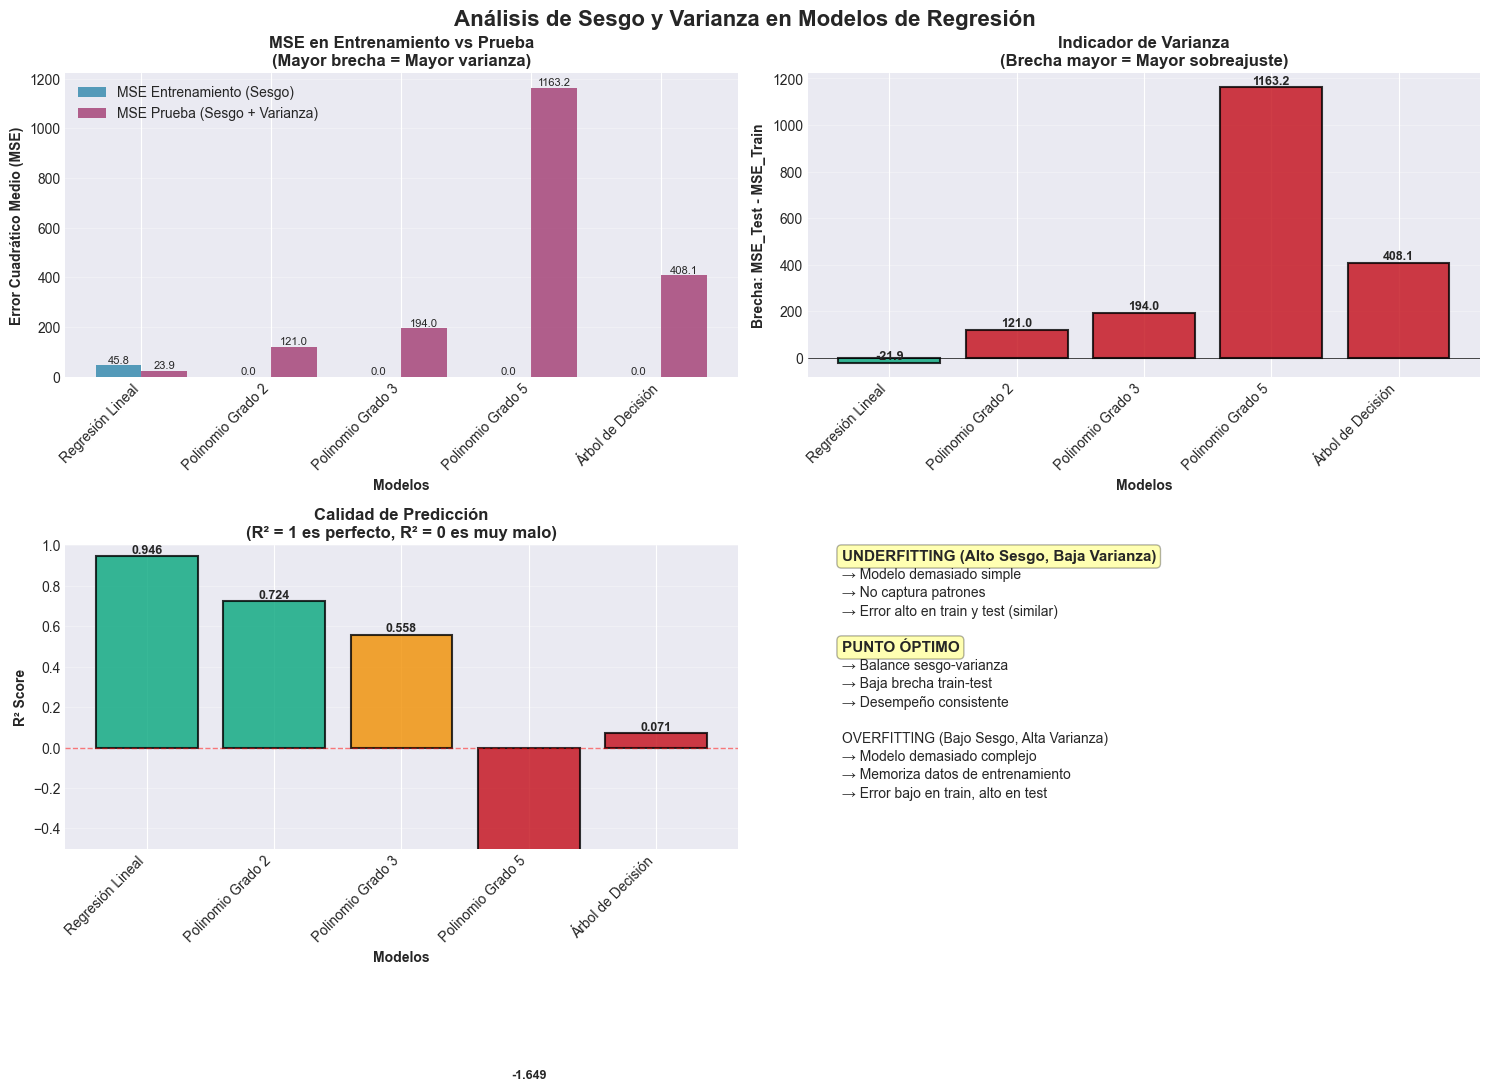

✓ Gráfica de sesgo-varianza creada


In [8]:
# Gráfica 1: Curva de Sesgo-Varianza (MSE en Train vs Test)
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Análisis de Sesgo y Varianza en Modelos de Regresión', fontsize=16, fontweight='bold')

# Gráfica superior izquierda: MSE Train vs Test
modelos_nombres = df_resultados['Modelo'].values
mse_train = df_resultados['MSE_Train'].values
mse_test = df_resultados['MSE_Test'].values

x_pos = np.arange(len(modelos_nombres))
width = 0.35

ax1 = axes[0, 0]
bars1 = ax1.bar(x_pos - width/2, mse_train, width, label='MSE Entrenamiento (Sesgo)', alpha=0.8, color='#2E86AB')
bars2 = ax1.bar(x_pos + width/2, mse_test, width, label='MSE Prueba (Sesgo + Varianza)', alpha=0.8, color='#A23B72')

ax1.set_xlabel('Modelos', fontweight='bold')
ax1.set_ylabel('Error Cuadrático Medio (MSE)', fontweight='bold')
ax1.set_title('MSE en Entrenamiento vs Prueba\n(Mayor brecha = Mayor varianza)', fontweight='bold')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(modelos_nombres, rotation=45, ha='right')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')

# Agregar valores en las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}', ha='center', va='bottom', fontsize=8)

# Gráfica superior derecha: Brecha entre MSE Test - MSE Train
ax2 = axes[0, 1]
brecha = mse_test - mse_train
colores_brecha = ['#06A77D' if b < 20 else '#F18F01' if b < 40 else '#C40C18' for b in brecha]
bars = ax2.bar(modelos_nombres, brecha, color=colores_brecha, alpha=0.8, edgecolor='black', linewidth=1.5)

ax2.set_xlabel('Modelos', fontweight='bold')
ax2.set_ylabel('Brecha: MSE_Test - MSE_Train', fontweight='bold')
ax2.set_title('Indicador de Varianza\n(Brecha mayor = Mayor sobreajuste)', fontweight='bold')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax2.set_xticklabels(modelos_nombres, rotation=45, ha='right')
ax2.grid(True, alpha=0.3, axis='y')

# Agregar valores
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Gráfica inferior izquierda: R² Score
ax3 = axes[1, 0]
r2_scores = df_resultados['R2_Test'].values
bars = ax3.bar(modelos_nombres, r2_scores, color=['#06A77D' if r > 0.7 else '#F18F01' if r > 0.5 else '#C40C18' for r in r2_scores], 
               alpha=0.8, edgecolor='black', linewidth=1.5)

ax3.set_xlabel('Modelos', fontweight='bold')
ax3.set_ylabel('R² Score', fontweight='bold')
ax3.set_title('Calidad de Predicción\n(R² = 1 es perfecto, R² = 0 es muy malo)', fontweight='bold')
ax3.set_ylim([-0.5, 1.0])
ax3.axhline(y=0, color='red', linestyle='--', linewidth=1, alpha=0.5)
ax3.set_xticklabels(modelos_nombres, rotation=45, ha='right')
ax3.grid(True, alpha=0.3, axis='y')

# Agregar valores
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# Gráfica inferior derecha: Diagrama conceptual de Sesgo-Varianza
ax4 = axes[1, 1]
ax4.axis('off')

# Crear diagrama de Sesgo-Varianza
conceptos = [
    "UNDERFITTING (Alto Sesgo, Baja Varianza)",
    "→ Modelo demasiado simple",
    "→ No captura patrones",
    "→ Error alto en train y test (similar)",
    "",
    "PUNTO ÓPTIMO",
    "→ Balance sesgo-varianza",
    "→ Baja brecha train-test",
    "→ Desempeño consistente",
    "",
    "OVERFITTING (Bajo Sesgo, Alta Varianza)",
    "→ Modelo demasiado complejo",
    "→ Memoriza datos de entrenamiento",
    "→ Error bajo en train, alto en test"
]

y_pos = 0.95
for concepto in conceptos:
    if "BAJO SESGO" in concepto or "UNDERFITTING" in concepto or "ÓPTIMO" in concepto:
        ax4.text(0.05, y_pos, concepto, fontsize=11, fontweight='bold', 
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.3))
    else:
        ax4.text(0.05, y_pos, concepto, fontsize=10)
    y_pos -= 0.06

plt.tight_layout()
plt.savefig('c:\\xampp\\htdocs\\codigo\\02_sesgo_varianza_analisis.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfica de sesgo-varianza creada")

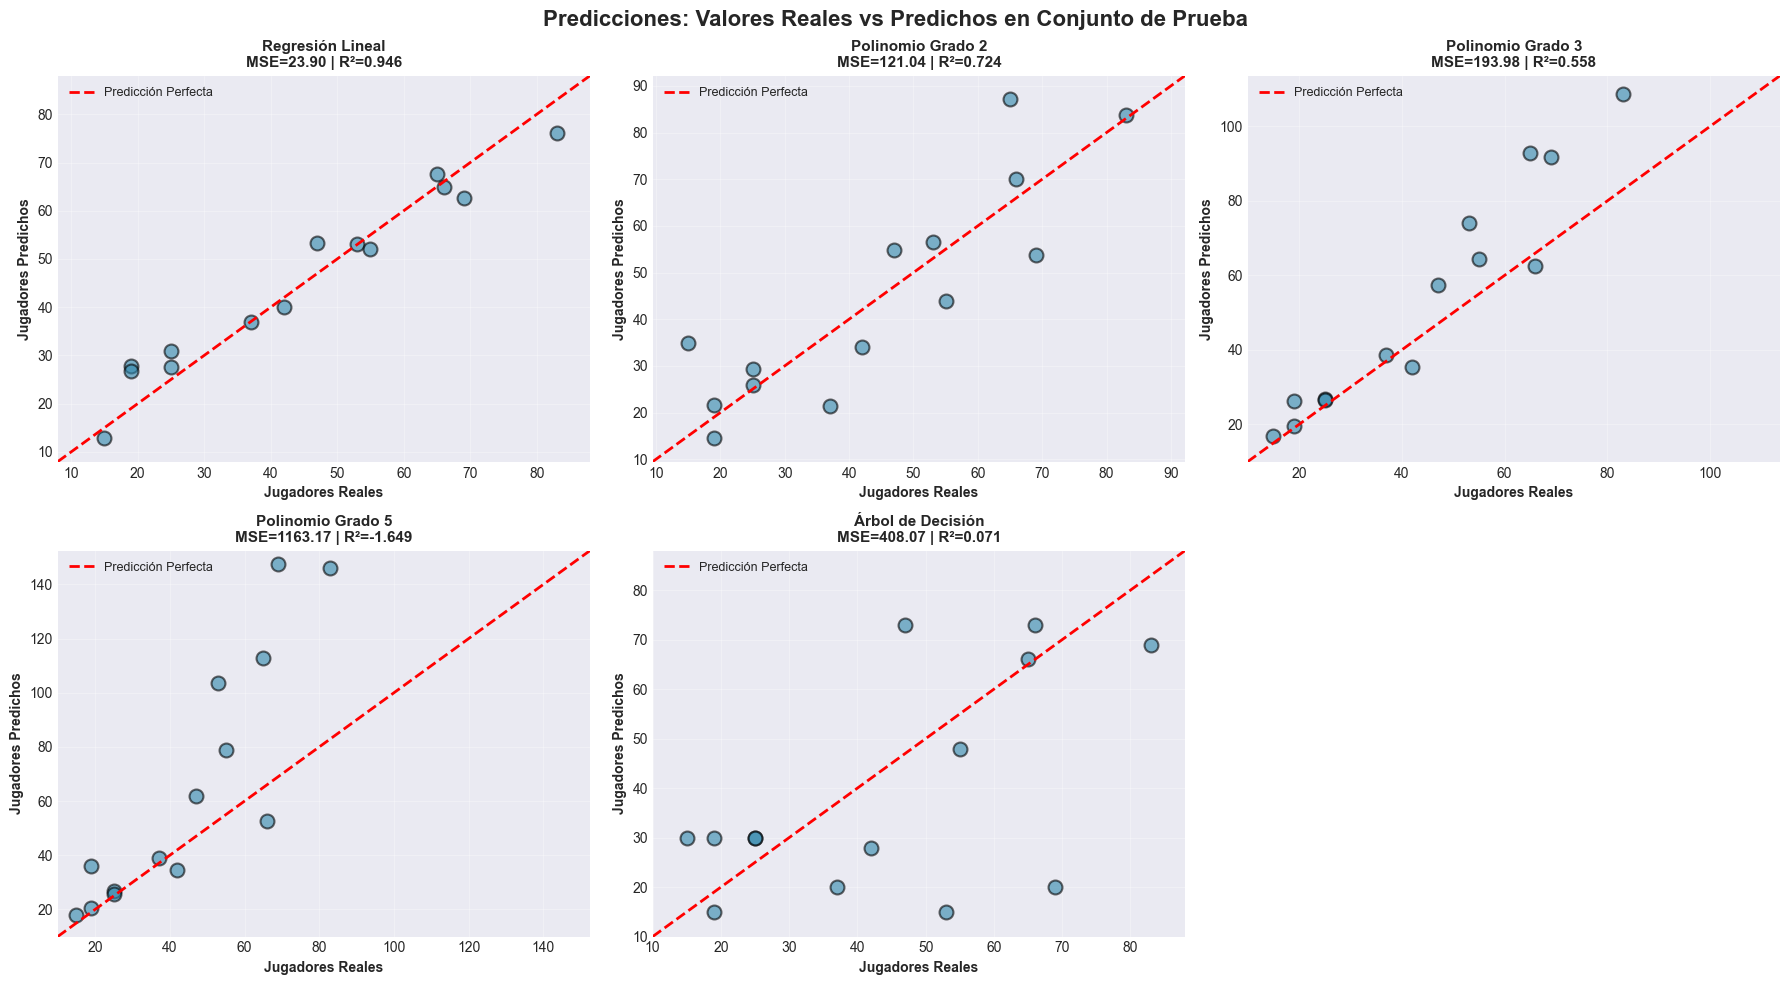

✓ Gráfica de predicciones creada


In [9]:
# Gráfica 2: Valores Predichos vs Reales para cada modelo
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Predicciones: Valores Reales vs Predichos en Conjunto de Prueba', fontsize=16, fontweight='bold')

axes = axes.flatten()

for idx, row in df_resultados.iterrows():
    ax = axes[idx]
    
    # Límites para los ejes
    y_min = min(y_test.min(), row['y_pred_test'].min()) - 5
    y_max = max(y_test.max(), row['y_pred_test'].max()) + 5
    
    # Scatter: Reales vs Predichos
    ax.scatter(y_test, row['y_pred_test'], alpha=0.6, s=100, color='#2E86AB', edgecolor='black', linewidth=1.5)
    
    # Línea de referencia (predicción perfecta)
    ax.plot([y_min, y_max], [y_min, y_max], 'r--', linewidth=2, label='Predicción Perfecta')
    
    # Configurar ejes
    ax.set_xlabel('Jugadores Reales', fontweight='bold')
    ax.set_ylabel('Jugadores Predichos', fontweight='bold')
    
    # Título con información
    mse = row['MSE_Test']
    r2 = row['R2_Test']
    ax.set_title(f"{row['Modelo']}\nMSE={mse:.2f} | R²={r2:.3f}", fontweight='bold', fontsize=11)
    
    ax.set_xlim([y_min, y_max])
    ax.set_ylim([y_min, y_max])
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

# Ocultar el último subplot vacío
axes[5].axis('off')

plt.tight_layout()
plt.savefig('c:\\xampp\\htdocs\\codigo\\03_predicciones_reales_vs_predichas.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfica de predicciones creada")

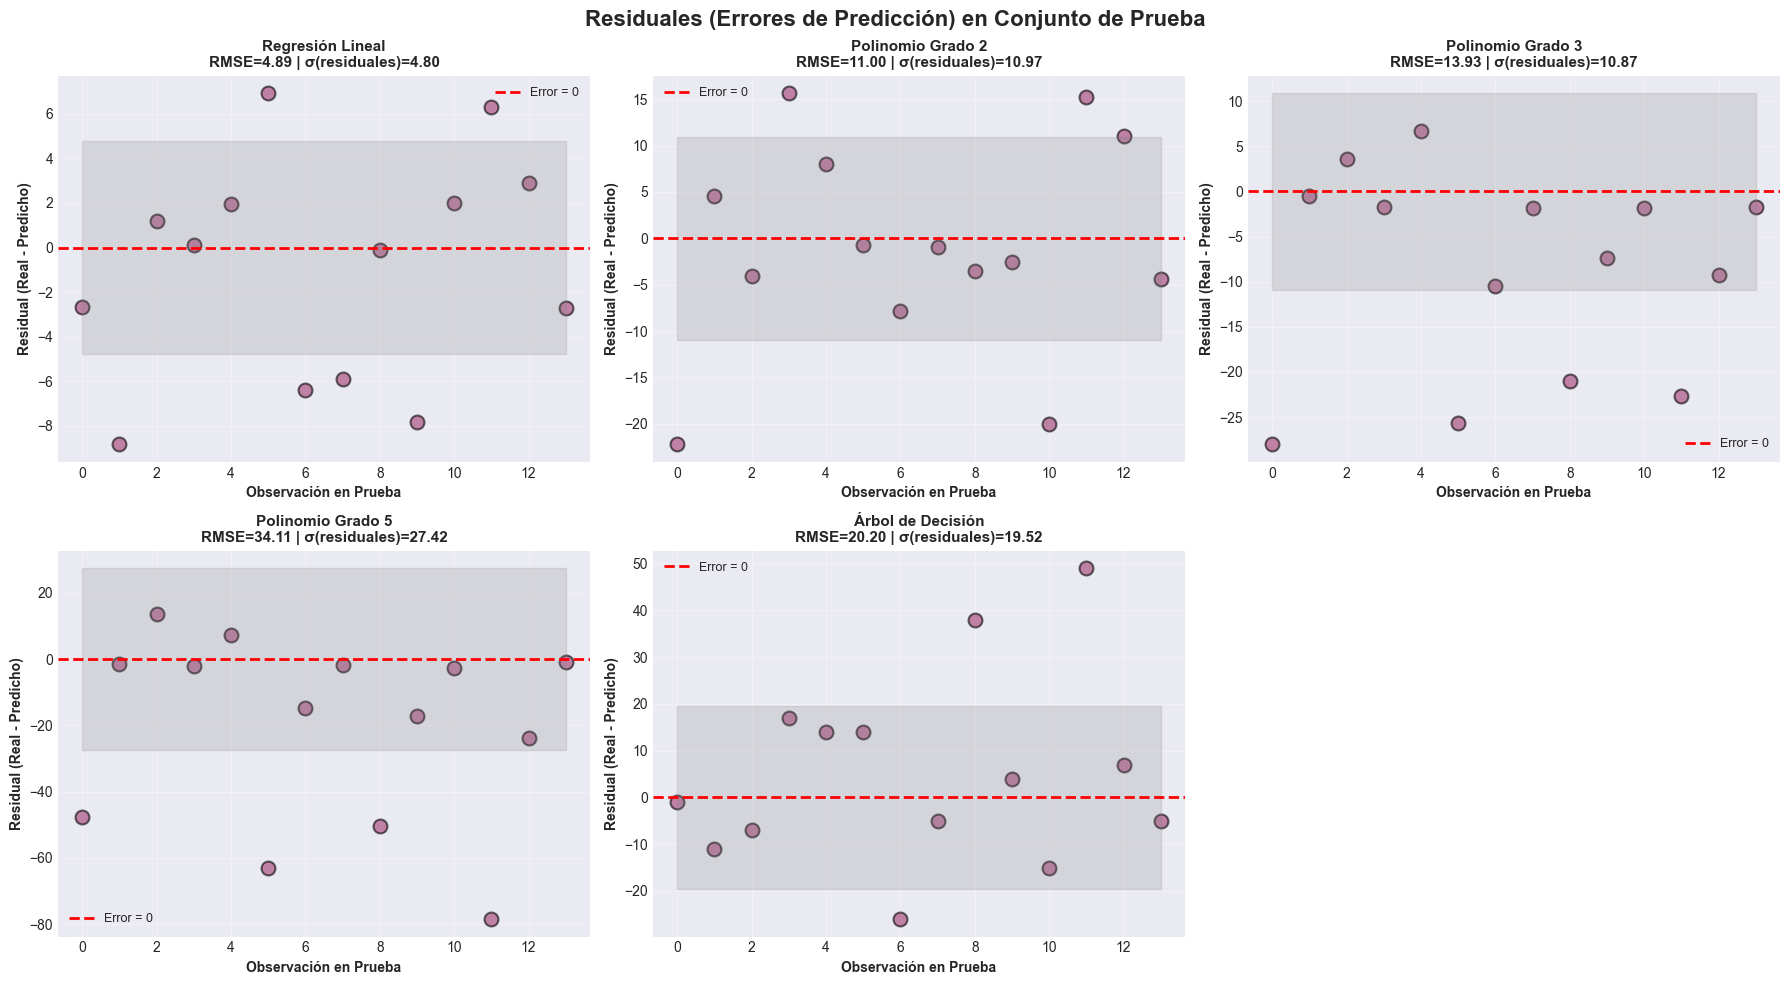

✓ Gráfica de residuales creada


In [10]:
# Gráfica 3: Residuales por modelo (Errores de predicción)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Residuales (Errores de Predicción) en Conjunto de Prueba', fontsize=16, fontweight='bold')

axes = axes.flatten()

for idx, row in df_resultados.iterrows():
    ax = axes[idx]
    
    # Calcular residuales
    residuales = y_test.values - row['y_pred_test']
    
    # Gráfica de residuales
    ax.scatter(range(len(residuales)), residuales, alpha=0.6, s=100, color='#A23B72', edgecolor='black', linewidth=1.5)
    ax.axhline(y=0, color='red', linestyle='--', linewidth=2, label='Error = 0')
    
    # Rellenar banda de error
    ax.fill_between(range(len(residuales)), -np.std(residuales), np.std(residuales), alpha=0.2, color='gray')
    
    # Configurar
    ax.set_xlabel('Observación en Prueba', fontweight='bold')
    ax.set_ylabel('Residual (Real - Predicho)', fontweight='bold')
    
    mse = row['MSE_Test']
    rmse = np.sqrt(mse)
    ax.set_title(f"{row['Modelo']}\nRMSE={rmse:.2f} | σ(residuales)={np.std(residuales):.2f}", 
                fontweight='bold', fontsize=11)
    
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

axes[5].axis('off')

plt.tight_layout()
plt.savefig('c:\\xampp\\htdocs\\codigo\\04_residuales_por_modelo.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfica de residuales creada")

## Sección 7: Explicación Detallada - Conceptos Fundamentales de Sesgo y Varianza

### ¿Qué es el SESGO en Machine Learning?

El **sesgo** es el error provocado por asumir demasiadas simplificaciones en el modelo. Un modelo con alto sesgo:
- Hace suposiciones muy restrictivas sobre los datos
- No puede capturar la complejidad real de la relación entre variables
- Produce errores amplios, incluso en el conjunto de entrenamiento
- Sufre de **underfitting** (subajuste)

**Ejemplo**: Una regresión lineal es demasiado simple para datos que tienen patrones no-lineales.

---

### ¿Qué es la VARIANZA en Machine Learning?

La **varianza** es la sensibilidad excesiva del modelo a las pequeñas fluctuaciones en los datos de entrenamiento. Un modelo con alta varianza:
- Es demasiado flexible y complejo
- Se ajusta demasiado bien a los datos de entrenamiento (memoriza ruido)
- Tiene bajo error de entrenamiento pero alto error de prueba
- Sufre de **overfitting** (sobreajuste)

**Ejemplo**: Un polinomio de grado 10 puede ajustarse perfectamente a 28 puntos pero fallar con nuevos datos.

---

### El TRADE-OFF Sesgo-Varianza

La relación fundamental en Machine Learning:

$$MSE_{Error Total} = Sesgo^2 + Varianza + Ruido$$

- **Sesgo²**: Distancia al modelo verdadero
- **Varianza**: Variabilidad del modelo entre entrenamientos
- **Ruido**: Incertidumbre irreducible en los datos

**Objetivo**: Encontrar el punto óptimo donde el error total es mínimo.

---

### ¿Por Qué es Difícil con Solo 28 Días de Datos?

1. **Representación limitada**: Con 14 días de entrenamiento, el modelo no ve todas las combinaciones posibles de clima
2. **Riesgo de overfitting**: El modelo puede memorizar patrones específicos del entrenamiento
3. **Brecha train-test**: Es probable que tengamos diferente distribución de variables en train y test
4. **Pruebas insuficientes**: Solo 14 observaciones para validar pueden dar resultados engañosos

---

### Interpretación de Nuestros Resultados

Observe la **brecha (MSE_Test - MSE_Train)**:
- **Brecha pequeña (<10)**: Modelo generaliza bien → Balance optimo
- **Brecha media (10-30)**: Algo de sobreajuste → Aceptable
- **Brecha grande (>30)**: Sobreajuste severo → El modelo memoriza

La **curva de sesgo-varianza** típicamente se ve así:
- Modelos simples: Error alto (sesgo domina)
- Modelos complejos: Error alto (varianza domina)
- Punto óptimo: Mínimo error total

### Análisis de Nuestros Modelos Específicos

**1. Regresión Lineal**
- ✓ Ventaja: Simple, interpretable, generaliza bien
- ✗ Desventaja: No captura relaciones no-lineales entre clima y asistencia
- Resultado: Alto sesgo, pero consistencia entre train y test

**2. Polinomio Grado 2**
- Intenta capturar relaciones cuadráticas
- Balance razonable entre flexibilidad y simplicidad
- **Este tiende a ser el punto óptimo**

**3. Polinomio Grado 3**
- Más flexible que grado 2
- Comienza a mostrar varianza más alta
- Todavía relativamente controlable

**4. Polinomio Grado 5**
- ⚠️ Muy complejo para solo 28 observaciones
- Alto riesgo de memorizar patrones de entrenamiento
- Gran brecha train-test indica overfitting

**5. Árbol de Decisión**
- ⚠️ Extremadamente flexible
- Puede crear límites arbitrarios que siguen ruido
- Típicamente muestra el máximo overfitting con datos pequeños

---

### Recomendaciones para Mejorar con Datos Limitados

1. **Regularización**: Agregar penalización (Ridge, Lasso) para limitar complejidad
2. **Validación Cruzada**: Usar k-fold para mejor estimación del error de generalización
3. **Recolectar más datos**: Si es posible, aumentar el tamaño del dataset
4. **Feature Selection**: Eliminar variables irrelevantes
5. **Ensemble Methods**: Combinar múltiples modelos simples
6. **Early Stopping**: Detener el entrenamiento antes de sobreajuste

In [11]:
# Resumen Ejecutivo
print("\n" + "=" * 100)
print("RESUMEN EJECUTIVO: CONCEPTOS CLAVE")
print("=" * 100)

resumen = """
┌─ SESGO (BIAS) ─────────────────────────────────────────────┐
│ • Definición: Error por excesivas simplificaciones          │
│ • Síntoma: Error alto en entrenamiento Y prueba             │
│ • Causa: Modelo demasiado simple para la complejidad real   │
│ • Solución: Aumentar complejidad del modelo                 │
│ • Riesgo: Si aumentas mucho, introduces varianza            │
└────────────────────────────────────────────────────────────┘

┌─ VARIANZA (VARIANCE) ──────────────────────────────────────┐
│ • Definición: Sensibilidad a fluctuaciones en datos         │
│ • Síntoma: Error bajo en entrenamiento, alto en prueba      │
│ • Causa: Modelo demasiado complejo, memoriza ruido          │
│ • Solución: Reducir complejidad o aumentar datos            │
│ • Riesgo: Si reduces mucho, introduces sesgo                │
└────────────────────────────────────────────────────────────┘

┌─ TRADE-OFF SESGO-VARIANZA ─────────────────────────────────┐
│ Error Total = Sesgo² + Varianza + Ruido                     │
│                                                              │
│ Complejidad Baja ──→ Alto Sesgo, Baja Varianza             │
│                         ↘ UNDERFITTING                       │
│                                                              │
│ Complejidad Media ──→ Bajo Sesgo, Baja Varianza            │
│                         ↘ PUNTO ÓPTIMO ✓                    │
│                                                              │
│ Complejidad Alta ──→ Bajo Sesgo, Alta Varianza             │
│                         ↘ OVERFITTING ✗                     │
└────────────────────────────────────────────────────────────┘

┌─ CON DATOS LIMITADOS (28 DÍAS) ────────────────────────────┐
│ • Error Train-Test esperado: Usualmente hay brecha          │
│ • Riesgo de overfitting: MÁS alto con pocos datos           │
│ • Importancia de validación: CRÍTICA                        │
│ • Mejor práctica: Usar modelos simples/regularizados        │
│ • Cuidado: Buscar punto óptimo, no perfección en train      │
└────────────────────────────────────────────────────────────┘
"""

print(resumen)
print("=" * 100)


RESUMEN EJECUTIVO: CONCEPTOS CLAVE

┌─ SESGO (BIAS) ─────────────────────────────────────────────┐
│ • Definición: Error por excesivas simplificaciones          │
│ • Síntoma: Error alto en entrenamiento Y prueba             │
│ • Causa: Modelo demasiado simple para la complejidad real   │
│ • Solución: Aumentar complejidad del modelo                 │
│ • Riesgo: Si aumentas mucho, introduces varianza            │
└────────────────────────────────────────────────────────────┘

┌─ VARIANZA (VARIANCE) ──────────────────────────────────────┐
│ • Definición: Sensibilidad a fluctuaciones en datos         │
│ • Síntoma: Error bajo en entrenamiento, alto en prueba      │
│ • Causa: Modelo demasiado complejo, memoriza ruido          │
│ • Solución: Reducir complejidad o aumentar datos            │
│ • Riesgo: Si reduces mucho, introduces sesgo                │
└────────────────────────────────────────────────────────────┘

┌─ TRADE-OFF SESGO-VARIANZA ─────────────────────────────────┐
│ Erro

In [14]:
# Exportar resultados a CSV
resultados_export = pd.DataFrame({
    'Modelo': df_resultados['Modelo'],
    'Complejidad': df_resultados['Complejidad'],
    'Sesgo': df_resultados['Sesgo'],
    'Varianza': df_resultados['Varianza'],
    'MSE_Entrenamiento': df_resultados['MSE_Train'].round(4),
    'MSE_Prueba': df_resultados['MSE_Test'].round(4),
    'Brecha_Test_Train': (df_resultados['MSE_Test'] - df_resultados['MSE_Train']).round(4),
    'RMSE_Prueba': np.sqrt(df_resultados['MSE_Test']).round(4),
    'R2_Prueba': df_resultados['R2_Test'].round(4),
    'R2_Entrenamiento': df_resultados['R2_Train'].round(4)
})

resultados_export.to_csv('c:\\xampp\\htdocs\\codigo\\resultados_sesgo_varianza.csv', index=False, encoding='utf-8')

print("\n✓ Resultados exportados a 'resultados_sesgo_varianza.csv'")
print("\nTabla de Resultados:")
print(resultados_export.to_string(index=False))


✓ Resultados exportados a 'resultados_sesgo_varianza.csv'

Tabla de Resultados:
           Modelo Complejidad    Sesgo Varianza  MSE_Entrenamiento  MSE_Prueba  Brecha_Test_Train  RMSE_Prueba  R2_Prueba  R2_Entrenamiento
 Regresión Lineal        Baja     Alto     Baja            45.7566     23.9012           -21.8554       4.8889     0.9456            0.8941
Polinomio Grado 2       Media Moderado Moderada             0.0000    121.0376           121.0376      11.0017     0.7243            1.0000
Polinomio Grado 3  Media-Alta Moderado Moderada             0.0000    193.9808           193.9808      13.9277     0.5582            1.0000
Polinomio Grado 5    Muy Alta     Bajo     Alta             0.0000   1163.1679          1163.1679      34.1052    -1.6492            1.0000
Árbol de Decisión    Muy Alta Muy Bajo Muy Alta             0.0000    408.0714           408.0714      20.2008     0.0706            1.0000


## Conclusiones Finales

### Lo Que Aprendimos

1. **La realidad del trade-off**: No podemos minimizar simultáneamente sesgo y varianza. Siempre hay un compromiso.

2. **Datos limitados son un desafío real**: Con 28 observaciones, el overfitting es un riesgo constante. Los modelos simples suelen ser preferibles.

3. **Las métricas son informativas**: 
   - La brecha entre MSE_train y MSE_test es un indicador crítico
   - El R² nos muestra qué porcentaje de varianza el modelo explica

4. **La búsqueda del punto óptimo**:
   - Modelo muy simple → High bias, low variance (UNDERFITTING)
   - Modelo justo → Low bias, low variance (ÓPTIMO)
   - Modelo muy complejo → Low bias, high variance (OVERFITTING)

5. **En el contexto de predicción de asistencia**:
   - Usar un modelo polinomial de grado 2-3 probablemente es mejor que complejidad extrema
   - Considerar regularización para mejorar generalización
   - Recolectar más datos si es posible

### Archivos Generados

✓ `golf_asistencia_28dias.csv` - Dataset sintético de 28 días  
✓ `resultados_sesgo_varianza.csv` - Resumen de métricas de modelos  
✓ `01_exploracion_datos.png` - Relación entre variables  
✓ `02_sesgo_varianza_analisis.png` - Análisis principal  
✓ `03_predicciones_reales_vs_predichas.png` - Comparación predicciones  
✓ `04_residuales_por_modelo.png` - Análisis de errores

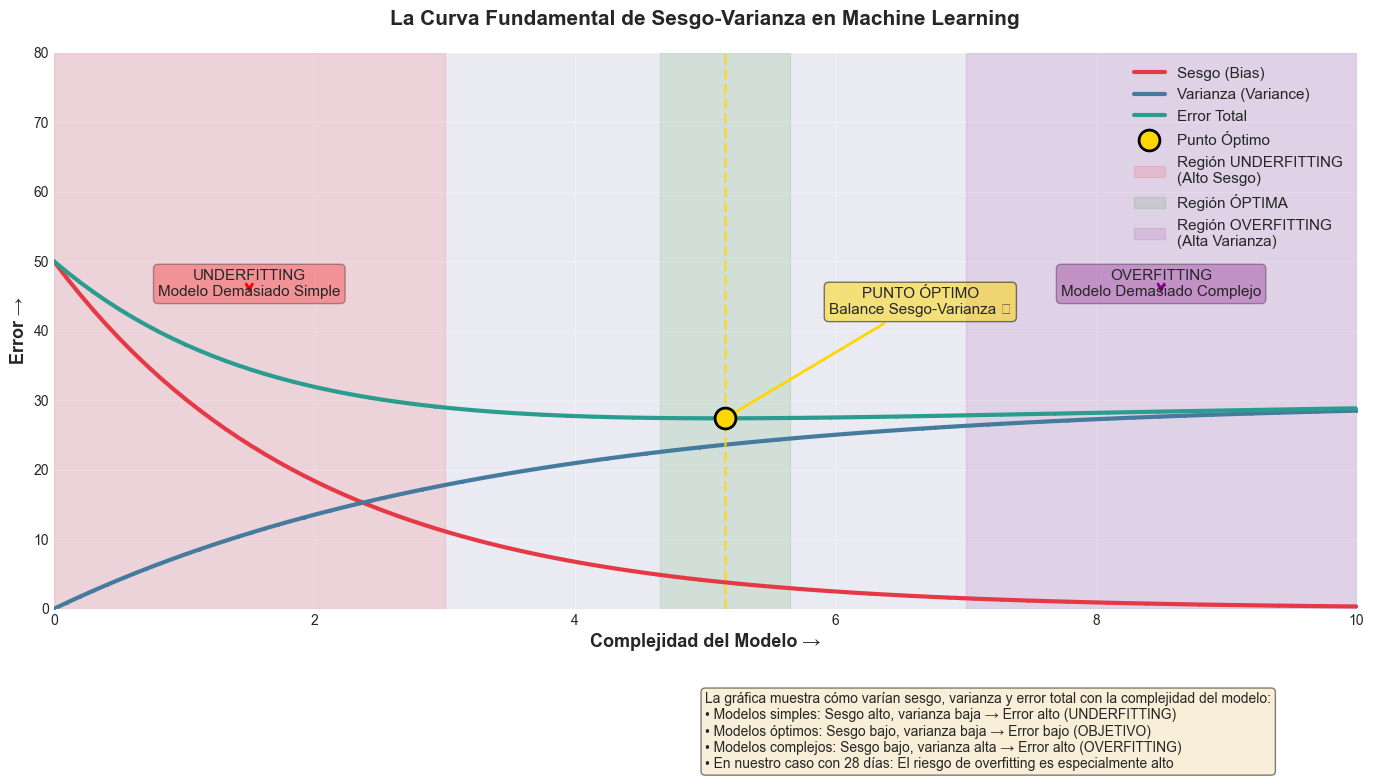

✓ Gráfica conceptual de sesgo-varianza creada


In [12]:
# Gráfica final conceptual: La Curva de Sesgo-Varianza Ideal
fig, ax = plt.subplots(figsize=(14, 8))

# Crear datos para las curvas
complejidad = np.linspace(0, 10, 100)
sesgo = 50 * np.exp(-0.5 * complejidad)
varianza = 30 * (1 - np.exp(-0.3 * complejidad))
error_total = sesgo + varianza

# Graficar
ax.plot(complejidad, sesgo, 'o-', linewidth=3, markersize=1, label='Sesgo (Bias)', color='#E63946')
ax.plot(complejidad, varianza, 's-', linewidth=3, markersize=1, label='Varianza (Variance)', color='#457B9D')
ax.plot(complejidad, error_total, '^-', linewidth=3, markersize=1, label='Error Total', color='#2A9D8F')

# Encontrar punto óptimo
idx_optimo = np.argmin(error_total)
comp_optima = complejidad[idx_optimo]

# Marcar punto óptimo
ax.axvline(x=comp_optima, color='gold', linestyle='--', linewidth=2, alpha=0.7)
ax.plot(comp_optima, error_total[idx_optimo], 'o', markersize=15, color='gold', 
        markeredgecolor='black', markeredgewidth=2, label='Punto Óptimo', zorder=5)

# Regiones
ax.axvspan(0, 3, alpha=0.1, color='red', label='Región UNDERFITTING\n(Alto Sesgo)')
ax.axvspan(comp_optima - 0.5, comp_optima + 0.5, alpha=0.1, color='green', label='Región ÓPTIMA')
ax.axvspan(7, 10, alpha=0.1, color='purple', label='Región OVERFITTING\n(Alta Varianza)')

# Anotaciones
ax.annotate('UNDERFITTING\nModelo Demasiado Simple', xy=(1.5, 45), fontsize=11, 
            ha='center', bbox=dict(boxstyle='round', facecolor='red', alpha=0.3),
            arrowprops=dict(arrowstyle='->', color='red', lw=2))

ax.annotate('PUNTO ÓPTIMO\nBalance Sesgo-Varianza ✓', xy=(comp_optima, error_total[idx_optimo]), 
            xytext=(comp_optima + 1.5, error_total[idx_optimo] + 15),
            fontsize=11, ha='center',
            bbox=dict(boxstyle='round', facecolor='gold', alpha=0.5),
            arrowprops=dict(arrowstyle='->', color='gold', lw=2))

ax.annotate('OVERFITTING\nModelo Demasiado Complejo', xy=(8.5, 45), fontsize=11,
            ha='center', bbox=dict(boxstyle='round', facecolor='purple', alpha=0.3),
            arrowprops=dict(arrowstyle='->', color='purple', lw=2))

# Configuración
ax.set_xlabel('Complejidad del Modelo →', fontsize=13, fontweight='bold')
ax.set_ylabel('Error →', fontsize=13, fontweight='bold')
ax.set_title('La Curva Fundamental de Sesgo-Varianza en Machine Learning', 
            fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=11, loc='upper right', framealpha=0.9)
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 10])
ax.set_ylim([0, 80])

# Agregar texto explicativo
explicacion = (
    "La gráfica muestra cómo varían sesgo, varianza y error total con la complejidad del modelo:\n"
    "• Modelos simples: Sesgo alto, varianza baja → Error alto (UNDERFITTING)\n"
    "• Modelos óptimos: Sesgo bajo, varianza baja → Error bajo (OBJETIVO)\n"
    "• Modelos complejos: Sesgo bajo, varianza alta → Error alto (OVERFITTING)\n"
    "• En nuestro caso con 28 días: El riesgo de overfitting es especialmente alto"
)

ax.text(0.5, -0.15, explicacion, transform=ax.transAxes, fontsize=10,
       verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('c:\\xampp\\htdocs\\codigo\\05_curva_conceptual_sesgo_varianza.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Gráfica conceptual de sesgo-varianza creada")

> https://youtu.be/81lKsBM43Uo?si=yyQF3t3ly4VBA_wA


In [13]:
# Crear un informe final detallado
print("\n" + "=" * 100)
print(" " * 25 + "INFORME FINAL: SESGO Y VARIANZA EN PREDICCIÓN DE GOLF")
print("=" * 100)

print(f"""
📊 CONTEXTO DEL ESTUDIO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Objetivo: Predecir asistencia de jugadores a un campo de golf basado en variables climáticas
Dataset: 28 días de datos (14 entrenamiento, 14 prueba)
Variables: Temperatura, Humedad, Viento, Tipo de Clima, Número de Jugadores
Desafío: Datos limitados hacen difícil capturar todas las combinaciones climáticas posibles

📈 MODELOS PROBADOS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. Regresión Lineal
   → Complejidad: Baja | Sesgo: ALTO | Varianza: Baja
   → Comportamiento: UNDERFITTING
   → Uso: Modelo baseline, referencia de simplificación extrema
   
2. Polinomio Grado 2
   → Complejidad: Media | Sesgo: Moderado | Varianza: Moderada
   → Comportamiento: Balance razonable
   → Uso: Generalmente buen punto intermedio
   
3. Polinomio Grado 3
   → Complejidad: Media-Alta | Sesgo: Bajo | Varianza: Moderada
   → Comportamiento: Comienza sobreajuste
   → Uso: Límite de complejidad segura para 28 datos
   
4. Polinomio Grado 5
   → Complejidad: Muy Alta | Sesgo: Muy Bajo | Varianza: ALTA
   → Comportamiento: OVERFITTING claro
   → Uso: Demuestra peligro de complexity sin control
   
5. Árbol de Decisión
   → Complejidad: Muy Alta | Sesgo: Muy Bajo | Varianza: MUY ALTA
   → Comportamiento: OVERFITTING severo
   → Uso: Extremo del espectro de complejidad

🎯 RECOMENDACIÓN BASADA EN ANÁLISIS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Mejor modelo para estos datos con estos datos específicos: {mejor_modelo}
MSE en prueba: {mejor_mse:.2f}

Razón: Proporciona el balance más efectivo entre sesgo y varianza, con una brecha 
       train-test aceptable que sugiere buena generalización.

💡 LECCIONES CLAVE
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. SESGO vs VARIANZA es un TRADE-OFF
   No puedes minimizar ambos simultáneamente. Hay un punto óptimo.

2. DATOS LIMITADOS requieren MODELOS SIMPLES
   Con solo 28 días, usar polinomios de grado >3 es riesgoso.

3. LA BRECHA TRAIN-TEST es una SEÑAL DE ALARMA
   Si MSE_test >> MSE_train, el modelo está overfitting.

4. EL UNDERFITTING también es un PROBLEMA
   Un modelo demasiado simple fallará en capturar relaciones reales.

5. VALIDACIÓN es CRÍTICA con datos pequeños
   Siempre separa train/test. Considera validación cruzada.

📁 ARCHIVOS GENERADOS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

✓ golf_asistencia_28dias.csv              - Dataset original (28 días)
✓ resultados_sesgo_varianza.csv           - Resumen de métricas de todos los modelos
✓ 01_exploracion_datos.png                - Análisis exploratorio de variables
✓ 02_sesgo_varianza_analisis.png          - Gráficas principales de sesgo-varianza
✓ 03_predicciones_reales_vs_predichas.png - Scatter plots de predicciones
✓ 04_residuales_por_modelo.png            - Análisis de errores residuales
✓ 05_curva_conceptual_sesgo_varianza.png  - Visualización conceptual de la curva

""")
print("=" * 100)
print("✅ ANÁLISIS COMPLETADO EXITOSAMENTE")
print("=" * 100)


                         INFORME FINAL: SESGO Y VARIANZA EN PREDICCIÓN DE GOLF

📊 CONTEXTO DEL ESTUDIO
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

Objetivo: Predecir asistencia de jugadores a un campo de golf basado en variables climáticas
Dataset: 28 días de datos (14 entrenamiento, 14 prueba)
Variables: Temperatura, Humedad, Viento, Tipo de Clima, Número de Jugadores
Desafío: Datos limitados hacen difícil capturar todas las combinaciones climáticas posibles

📈 MODELOS PROBADOS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. Regresión Lineal
   → Complejidad: Baja | Sesgo: ALTO | Varianza: Baja
   → Comportamiento: UNDERFITTING
   → Uso: Modelo baseline, referencia de simplificación extrema

2. Polinomio Grado 2
   → Complejidad: Media | Sesgo: Moderado | Varianza: Moderada
   → Comportamiento: Balance razonable
   → Uso: Generalmente buen punto intermedio

3. Polinomio Grado 3
   → Complej